   Year        T2M       RH2M  PRECTOTCORR District_Name      NDVI     Yield  \
0  2015  26.667507  44.516877       629.19       Lucknow  0.490388  2.368930   
1  2016  26.608907  46.551257       869.86       Lucknow  0.382516  2.670001   
2  2017  26.421589  48.908712       960.07       Lucknow  0.378340  2.580003   
3  2018  26.099068  50.693671      1216.01       Lucknow  0.382765  2.730016   
4  2019  25.414192  57.753973      1122.86       Lucknow  0.394574  2.661996   

   Temp_Anomaly  Rain_Anomaly  Humidity_Anomaly  Climate_Anomaly_Score  \
0      1.189581     -1.188487         -1.341736               3.719804   
1      1.107125     -0.199721         -0.979884               2.286731   
2      0.843551      0.170896         -0.560567               1.575014   
3      0.389733      1.222396         -0.243079               1.855208   
4     -0.573955      0.839700          1.012726               2.426381   

  Climate_Risk_Level  
0          High Risk  
1      Moderate Risk  
2    

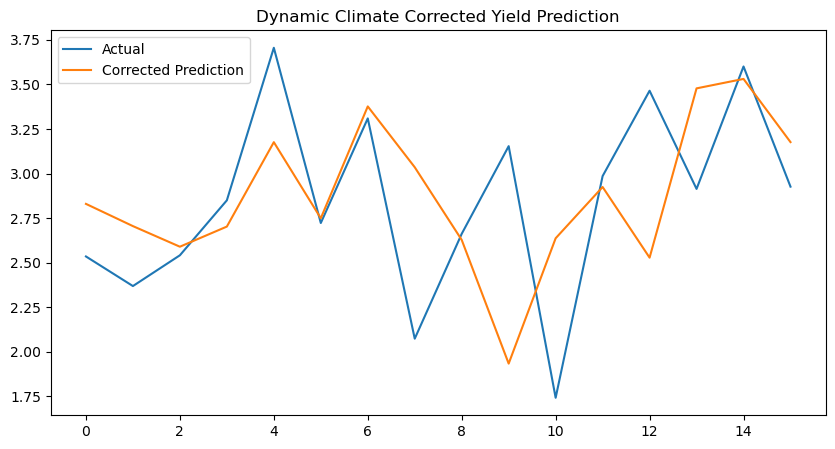


Dynamic climate correction results saved!


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# =====================================
# LOAD DATASET
# =====================================

df = pd.read_csv(
    "../datasets/climate_anomaly_dataset.csv"
)

print(df.head())


# =====================================
# FEATURES & TARGET
# =====================================

X = df[[
    'T2M',
    'RH2M',
    'PRECTOTCORR',
    'NDVI',
    'Climate_Anomaly_Score'
]]

y = df['Yield']


# =====================================
# TRAIN TEST SPLIT
# =====================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# =====================================
# XGBOOST MODEL
# =====================================

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)


# =====================================
# PREDICTIONS
# =====================================

y_pred = model.predict(X_test)


# =====================================
# DYNAMIC CLIMATE CORRECTION
# =====================================

corrected_predictions = []

for pred, anomaly in zip(
    y_pred,
    X_test['Climate_Anomaly_Score']
):

    # High climate instability
    if anomaly > 3:

        corrected_pred = pred * 0.90

    # Moderate instability
    elif anomaly > 1.5:

        corrected_pred = pred * 0.95

    # Normal climate
    else:

        corrected_pred = pred

    corrected_predictions.append(corrected_pred)


# =====================================
# EVALUATION
# =====================================

mae = mean_absolute_error(
    y_test,
    corrected_predictions
)

mse = mean_squared_error(
    y_test,
    corrected_predictions
)

rmse = mse ** 0.5

r2 = r2_score(
    y_test,
    corrected_predictions
)

print("\nDYNAMIC CLIMATE CORRECTION RESULTS")

print(f"MAE  : {mae}")

print(f"RMSE : {rmse}")

print(f"R2   : {r2}")


# =====================================
# VISUALIZATION
# =====================================

plt.figure(figsize=(10,5))

plt.plot(
    y_test.values,
    label='Actual'
)

plt.plot(
    corrected_predictions,
    label='Corrected Prediction'
)

plt.legend()

plt.title(
    "Dynamic Climate Corrected Yield Prediction"
)

plt.show()


# =====================================
# SAVE RESULTS
# =====================================

results_df = pd.DataFrame({
    'Actual_Yield': y_test.values,
    'Corrected_Prediction': corrected_predictions
})

results_df.to_csv(
    "../results/dynamic_climate_results.csv",
    index=False
)

print("\nDynamic climate correction results saved!")